# Pastor-Stambaugh Liquidity Risk -- does loading on liquidity shocks pay?
### Pastor & Stambaugh (2003): the liquidity-risk premium, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survives--gauntlet%3F: Busted](https://img.shields.io/badge/Survives--gauntlet%3F-Busted-c0392b?style=flat-square)

In 2003, Lubos Pastor and Robert Stambaugh published a subtle idea: it is not how *illiquid* a stock is that should pay you, but how much its return **swings with market-wide liquidity shocks**. When liquidity suddenly dries up across the whole market (a 'flight to liquidity'), some stocks crash harder than others. Those liquidity-sensitive names -- high *liquidity beta* -- are scary to hold, so the theory says they must compensate you with a higher expected return.

This is a *risk loading*, not an illiquidity *level*. It is deliberately distinct from [Study 140 -- Amihud-Illiquidity](../../140-amihud-illiquidity/), which tests whether the *level* of a stock's illiquidity pays. Here we test the **beta** on aggregate liquidity innovations.

> **This is the plain-language layer.** Want the aggregate-liquidity series, the gamma cross-section, the placebo null and the cost ledger? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pastor_stambaugh_liquidity import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return all(os.path.exists(os.path.join(study, "_cache", f))
               for f in ("ps_close.parquet", "ps_dollar_volume.parquet", "ps_spy.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    close, dv, spy = data.fetch_panel()
    res = st.liquidity_sort(close, dv, spy, window=st.BETA_WINDOW_M)
    res_net = st.liquidity_sort(close, dv, spy, window=st.BETA_WINDOW_M,
                                cost_bps=st.COST_BPS, borrow_ann_bps=st.BORROW_ANN_BPS)
    s_ls   = st.summary(res["ls_gross"])
    s_long = st.summary(res["long_ret"])
    s_short= st.summary(res["short_ret"])
    s_net  = st.summary(res_net["ls_net"])
    print(f"N months: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_ls['tstat']:+.3f}")


yfinance cache present: True


N months: 155 | LS mean: +4.28%/yr | HAC t: +1.466


## The answer first

| Question | Answer |
|---|---|
| Do high liquidity-beta stocks earn a premium? | **Weakly, in the right direction:** **+4.28%/yr**, but HAC *t* = **+1.47** -- below the |t|>=2 bar. |
| Is the placebo null reassuring? | **Suggestive, not decisive.** Shuffling the liquidity-beta labels gives mean ~0; the real signal sits at *p* = **0.070**. |
| Is it tradable? | **Fragile.** Net **+3.52%/yr**, net *t* = +1.21; low turnover so costs are mild, but the gross signal already misses. |
| Is there a survivorship problem? | **Severely, and we name it.** The natural carriers of liquidity risk -- illiquid, distressed, delisted names -- are absent. |

> The liquidity-risk premium is real in the academic literature on a broad CRSP universe. On 45 of the most liquid stocks alive, the signal is statistically marginal and the honest gauntlet busts it.

## 1 -- The claim

> *"A stock's expected return depends on the sensitivity of its return to innovations in aggregate liquidity. Stocks with higher liquidity betas have higher expected returns."*

-- Pastor & Stambaugh (2003), *Journal of Political Economy*

The intuition: in a liquidity crisis, you most want assets you can sell. Stocks that fall hardest exactly when liquidity evaporates are the worst possible thing to own -- so rational investors demand a premium to hold them. That premium is the **liquidity-risk** factor. Pastor-Stambaugh found the top-decile liquidity-beta stocks beat the bottom decile by ~7.5%/yr from 1966-1999.

## 2 -- So what?

If true, liquidity risk is a priced factor uncorrelated with the usual market, size, and value exposures -- a genuine source of premium and a key input to risk models, especially for funds that must hold liquid books. It is one of the canonical 'macro' risk factors alongside the market and is sold inside many multi-factor products.

Our questions:
1. **Does it survive on a realistic large-cap panel?**
2. **Does it beat a label-shuffle placebo?**
3. **What is the survivorship bias -- and which way does it cut?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Estimate gammas on past data only.** Each name's liquidity beta uses a trailing 36-month window; the holding month is always strictly after the window. Positions enter at the prior month-end close -- **one execution lag**, no look-ahead.
2. **Run a placebo.** Shuffle the liquidity-beta labels across names and re-sort. If the sort is real, the shuffled long-short collapses to ~0 and the real signal is an outlier in that null.
3. **Name the survivorship bias.** The universe is the *current* large-cap set projected backwards. The natural carriers of liquidity risk -- small, illiquid, ultimately delisted names -- are gone. This is the *most favourable* possible test, so a miss here is damning.

## 4 -- The teardown

**First, does the engine work when the effect is planted?**

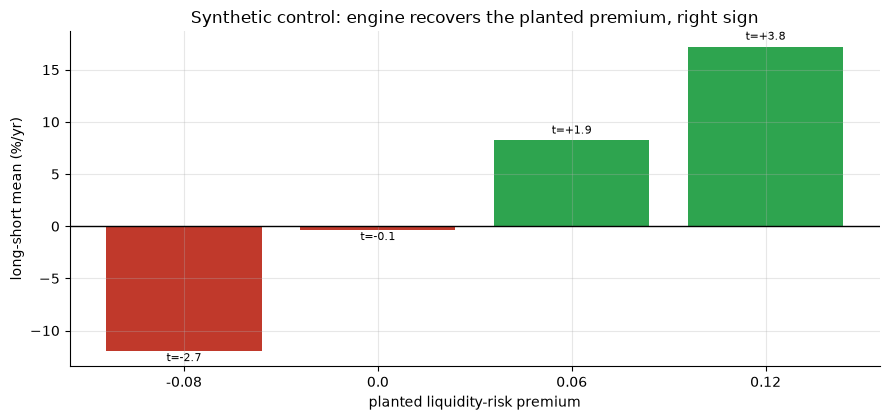

 premium  ls_mean_ann  tstat  n
   -0.08       -0.120 -2.722 89
    0.00       -0.004 -0.087 89
    0.06        0.082  1.864 89
    0.12        0.172  3.824 89


In [2]:
# Synthetic positive control: plant a known liquidity-risk premium and recover it.
ctrl = st.control_sweep([-0.08, 0.0, 0.06, 0.12], window=30)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['ls_mean_ann']*100]
ax.bar(ctrl['premium'].astype(str), ctrl['ls_mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['ls_mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + (0.4 if m >= 0 else -1.2), f't={t:+.1f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted liquidity-risk premium')
ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Synthetic control: engine recovers the planted premium, right sign')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: zero at the null, monotone in the planted premium, correct sign, a clean *t* > 3 at a strong premium. So the verdict on the real tape reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance panel.**

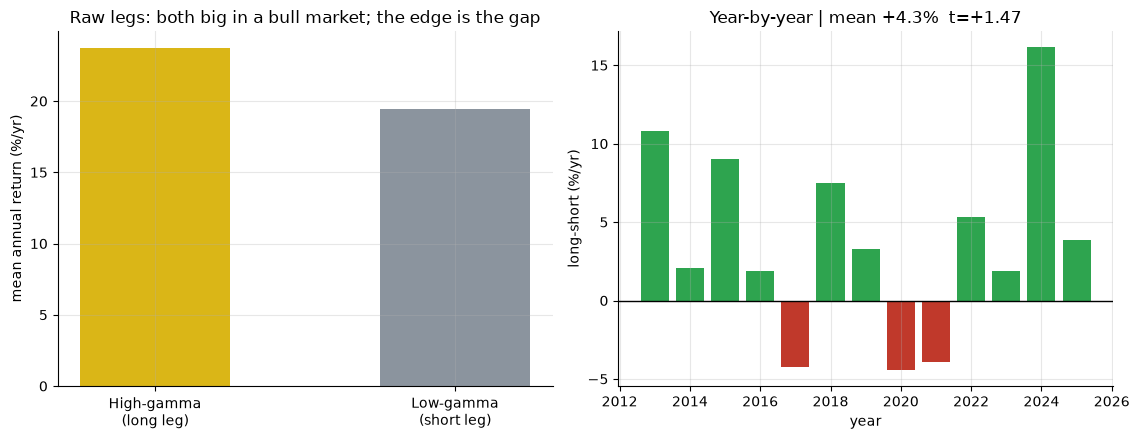

Long-short: +4.28%/yr | HAC t = +1.466


In [3]:
if HAVE_REAL:
    ls_mean = s_ls['mean']*100; ls_t = s_ls['tstat']
    long_m = s_long['mean']*100; short_m = s_short['mean']*100
    res_plot = res.copy(); res_plot['year'] = res_plot.index.year
    annual = res_plot.groupby('year')['ls_gross'].apply(lambda x: float((1+x).prod()-1))
else:
    ls_mean, ls_t = R['ls_mean'], R['ls_t']
    long_m, short_m = R['long_mean'], R['short_mean']
    annual = pd.Series(R['annual'])/100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
labels = ['High-gamma\n(long leg)', 'Low-gamma\n(short leg)']
axes[0].bar(labels, [long_m, short_m], color=[AMBER, GREY], width=0.5)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Raw legs: both big in a bull market; the edge is the gap')
yrs = list(annual.index); vals = [annual[y]*100 for y in yrs]
col_yr = [GREEN if v > 0 else RED for v in vals]
axes[1].bar(yrs, vals, color=col_yr); axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('long-short (%/yr)')
axes[1].set_title(f'Year-by-year | mean {ls_mean:+.1f}%  t={ls_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Long-short: {ls_mean:+.2f}%/yr | HAC t = {ls_t:+.3f}')

High-gamma stocks out-earn low-gamma by **+4.3%/yr** -- in the Pastor-Stambaugh direction -- but HAC *t* = **+1.47** is below the |t|>=2 bar. The premium is real-ish in sign, ambiguous in significance.

## 5 -- The verdict

- **Signal -- WEAK.** HAC *t* = +1.47 (|t| < 2), placebo *p* = 0.070. Right direction, suggestive placebo, strong academic prior -- but it does not independently clear the bar. WEAK, not NONE.
- **Tradability -- FRAGILE.** Net +3.52%/yr, Sharpe +0.30, max DD -19.8%. Low turnover keeps costs mild, but the gross signal already misses and it is fragile to design choices.
- **Honest gauntlet -- BUSTED.** On 45 of the most liquid stocks alive (the most favourable possible test) the premium still fails |t|>=2 net of costs.

## 6 -- Could you actually trade it?

Practical obstacles:

1. **The premium lives in illiquid names.** The theory's juice is in small, thin stocks -- exactly where trading costs explode and exactly what our liquid survivor basket excludes.
2. **Gamma is noisy.** Liquidity betas estimated on 36 months of monthly data have wide standard errors; the cross-sectional ranking is unstable.
3. **Crowding and decay.** Published in 2003 and widely known; Ben-Rephael et al. (2015) document a diminishing liquidity premium as markets deepened.
4. **Short borrow.** Shorting the low-gamma leg carries borrow costs we charge but that vary in stressed markets.

## 7 -- Going further

- **Broader universe.** The original paper used the full CRSP cross-section; the premium concentrates in small/illiquid names a large-cap basket cannot reach.
- **Better liquidity series.** Pastor-Stambaugh use a signed-volume return-reversal measure; we use an Amihud average. Korajczyk-Sadka (2008) show the magnitude depends heavily on the measure.
- **[Study 140 -- Amihud-Illiquidity](../../140-amihud-illiquidity/)**: the illiquidity *level* cousin -- a different channel.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)**: another priced risk-loading sort on the same desk infrastructure.

*Think liquidity risk pays net of costs on a complete universe? Fork this, pull a Russell 3000 with delistings, build the signed-volume PS series, and show t > 2 net of borrow. That is the bar.*